In [1]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

In [2]:
wedding = pd.read_csv('RSVPResponses.csv')
df = pd.DataFrame(wedding)

Here you want to import your csv from "The Knot" or wherever you are managing your guest list. Since later on we utilize the Party column which is a degault option listed from "The Knot" I would recommend using the site to manage guests. Plus keep up with the times everything is online now so I would expect this to be the case move forward 5 years until our AI bots are doing reservations for us. 

Additionally, I did do some formatting to the table containing our Full Name, Party, and Attendance. My approach utilizes an additional cost of the bride/groom relationship to the cost function. Therefore, it is necessary to utilize an encoded column for "Knows Bride" and "Knows Groom" in order for this to work. I manually inputted these values for my wedding however, the flexability of The Knot allows you to ask questions to your guest when they RSVP. A question could be added to the RSVP to collect this information if you did not want to expend the manual effort. 

In [4]:
df['Full Name'] = df['First Name'] + " " + df['Last Name']
columns = df.columns.tolist() 
columns.insert(0, columns.pop(columns.index('Full Name')))
df = df[columns]

df = df[df['Wedding Day - RSVP'] == 'Attending']

This is data cleaning from the raw extract you get from The Knot.

In [5]:
guest_list = df[['Full Name', 'Party', 'Knows Bride', 'Knows Groom']]
pairs = list(combinations(guest_list['Full Name'], 2))
relationship_edges = []

for person1, person2 in pairs:
    # Get the data for both persons
    person1_data = guest_list.loc[guest_list['Full Name'] == person1]
    person2_data = guest_list.loc[guest_list['Full Name'] == person2]

    if person1_data.empty or person2_data.empty:
        continue

    person1_data = person1_data.iloc[0]
    person2_data = person2_data.iloc[0]
    
    # Initialize relationship score
    relationship = 0

    # Check if they belong to the same party
    if person1_data['Party'] == person2_data['Party']:
        relationship -= 50
    
    # Check if both know the bride
    if person1_data['Knows Bride'] == 1 and person2_data['Knows Bride'] == 1:
        relationship -= 25

    # Check if both know the groom
    if person1_data['Knows Groom'] == 1 and person2_data['Knows Groom'] == 1:
        relationship -= 25

    # Append the edge to the list
    relationship_edges.append({
        'Person 1': person1,
        'Person 2': person2,
        'Relationship': relationship
    })

# Create a DataFrame for the relationship edges
relationship_edges_df = pd.DataFrame(relationship_edges)
relationships_edges = { (row['Person 1'], row['Person 2']): row['Relationship'] for idx, row in relationship_edges_df.iterrows() }


Okay now, we get into the fun stuff. First we need to know our guest list and idenfity the data that will influnece the prediction. Let's take the Full Name, Party, Knows Bride, and Knows Groom columns and put them in a dataframe. Next we will need to make pairs for each combination of persons attending the wedding. This will be important into calculating the cost of each pair.

Next we have a loop the goes throguh each pair and grabs the associated data from each person and calculates a score for each person sitting with one another at a table. This will allow us to get a comprhensive cost calculate for each person sitting with one another. Essentially, it is counting the likelyhood based off of the critera "is the person in the same party" and "does the person also know the bride/groom" for each other person. 

The result is a matrix of the cost of each person sitting with each person. Say for example we had only 4 people attending. The resulting matrix would show at column 1, row 2 the cost of person 1 sitting with person 2. Likewise row 1 column 2 would show the same as the column and rows represent the entire guest list. Another example row 2 and column 4 would show the cost of person 2 sitting with person 4. 

In [6]:
# Initialize the graph
temp_graph = nx.Graph()

# Add nodes (guests)
temp_graph.add_nodes_from(guest_list['Full Name'])

# Add edges with weights (relationships)
for (person1, person2), weight in relationships_edges.items():
    temp_graph.add_edge(person1, person2, weight=weight)

# Convert the graph to an adjacency matrix with weights using the unique nodelist
relationships_mat_unnormed = nx.to_numpy_array(temp_graph, nodelist=guest_list['Full Name'], weight='weight')

# Normalize the matrix (dividing by 100 to scale)
relationships_mat = relationships_mat_unnormed / 100

# Print the resulting matrix
print("Adjacency Matrix (Normalized):")
relationships_mat

Adjacency Matrix (Normalized):


array([[ 0.  , -0.75, -0.75, -0.75, -0.25, -0.25, -0.25, -0.25, -0.25,
        -0.25, -0.25],
       [-0.75,  0.  , -0.75, -0.75, -0.25, -0.25, -0.25, -0.25, -0.25,
        -0.25, -0.25],
       [-0.75, -0.75,  0.  , -0.75, -0.25, -0.25, -0.25, -0.25, -0.25,
        -0.25, -0.25],
       [-0.75, -0.75, -0.75,  0.  , -0.25, -0.25, -0.25, -0.25, -0.25,
        -0.25, -0.25],
       [-0.25, -0.25, -0.25, -0.25,  0.  , -0.75, -0.75, -0.25, -0.25,
        -0.25, -0.25],
       [-0.25, -0.25, -0.25, -0.25, -0.75,  0.  , -0.75, -0.25, -0.25,
        -0.25, -0.25],
       [-0.25, -0.25, -0.25, -0.25, -0.75, -0.75,  0.  , -0.25, -0.25,
        -0.25, -0.25],
       [-0.25, -0.25, -0.25, -0.25, -0.25, -0.25, -0.25,  0.  , -0.75,
        -0.75, -0.75],
       [-0.25, -0.25, -0.25, -0.25, -0.25, -0.25, -0.25, -0.75,  0.  ,
        -0.75, -0.75],
       [-0.25, -0.25, -0.25, -0.25, -0.25, -0.25, -0.25, -0.75, -0.75,
         0.  , -0.75],
       [-0.25, -0.25, -0.25, -0.25, -0.25, -0.25, -0.25, -0.

In [ ]:
table_size = 4

table_count = 5

Adjust the above given the seating available at the wedding.

In [8]:
def generate_random_seating(table_count, guest_list):
    num_guests = len(guest_list)
    seating_arrangement = np.zeros((table_count, num_guests), dtype=int)
    for guest_index in range(num_guests):
        table_index = np.random.choice(table_count)
        seating_arrangement[table_index, guest_index] = 1
    return seating_arrangement

def reshape_to_table_seats(x, table_count, num_guests):
    if x.shape[0] != table_count or x.shape[1] != num_guests:
        raise ValueError(f"Invalid shape for x. Expected ({table_count}, {num_guests})")
    return x

# Cost function
def cost(x, relationships_mat):
    table_seats = reshape_to_table_seats(x, x.shape[0], x.shape[1])
    table_costs = 0
    for table in range(table_seats.shape[0]):
        seated_guests = np.where(table_seats[table] == 1)[0]
        for i in range(len(seated_guests)):
            for j in range(i + 1, len(seated_guests)):
                guest_i = seated_guests[i]
                guest_j = seated_guests[j]
                table_costs += relationships_mat[guest_i, guest_j]
    return table_costs

# Move a guest to a new table
def move_guest(table_seats, guest_idx, from_table, to_table):
    table_seats[from_table, guest_idx] = 0
    table_seats[to_table, guest_idx] = 1
    return table_seats

# Take a step to generate a new seating arrangement
def take_step(x, table_count, table_size):
    table_seats = np.copy(x)
    num_guests = x.shape[1]
    guest_idx = np.random.choice(num_guests)
    from_table = np.where(table_seats[:, guest_idx] == 1)[0][0]
    valid_tables = [i for i in range(table_count) if i != from_table and np.sum(table_seats[i]) < table_size]
    if not valid_tables:
        return table_seats
    to_table = np.random.choice(valid_tables)
    return move_guest(table_seats, guest_idx, from_table, to_table)

# Probability of accepting a move
def prob_accept(cost_old, cost_new, temp):
    if cost_new < cost_old:
        return 1.0
    return np.exp((cost_old - cost_new) / temp)

# Map seating arrangement to guest names
def display_seating_arrangement(seating, guest_list):
    seating_arrangement = []
    for table in range(seating.shape[0]):
        table_guests = guest_list[np.where(seating[table] == 1)[0]]
        seating_arrangement.append(list(map(str, table_guests)))  # Ensure all items are strings
    for table_num, guests in enumerate(seating_arrangement):
        print(f"Table {table_num + 1}: {', '.join(guests)}")

The above are our functions that we are making to calculate the cost of each table. Above we calculated the cost of each person sitting next to each other. Now we need to take that relationship and create a cost for an entire table and minimize that cost to find the optimal seating arrangement. 

To start this process first we need a random seating arrangment. This process is essentially a batching process and moves guests from one table to the next and calculates a new score to then determine a probability of accepting that new assignmignet. So we take a random arrangment and then we have a funtiont that moves one person from one table to another table. This is now when we have our next funtion that takes the current table arrangement moves one person to take one step. The probability accept funtion is called to the calculate the difference of the score between the old score and the new score (encompassing the total cost of all of the tables) If the cost of the new arrangment is less that the old score we want to keep that person there as the cost funtion has been reduced. 

In [9]:
# Simulated Annealing
def anneal(
    initial_seating, relationships_mat, table_count, table_size, 
    temp=1.0, temp_min=0.00001, alpha=0.9, n_iter=100, audit=False
):
    pos_current = np.copy(initial_seating)
    cost_old = cost(pos_current, relationships_mat)
    audit_trail = []  # To track progress if `audit` is enabled

    while temp > temp_min:
        for _ in range(n_iter):
            pos_new = take_step(pos_current, table_count, table_size)
            cost_new = cost(pos_new, relationships_mat)

            # Determine acceptance probability
            p_accept = prob_accept(cost_old, cost_new, temp)

            # Decide to move to the new solution
            if p_accept > np.random.random():
                pos_current = pos_new
                cost_old = cost_new

            # Audit the details for visualization
            if audit:
                audit_trail.append((cost_new, cost_old, temp, p_accept))

        # Decrease the temperature
        temp *= alpha

    # Return final seating, cost, and audit details if enabled
    return (pos_current, cost_old, audit_trail if audit else None)

The simulated annealing repeats the moving of persons and calculation of table scores for each combination until an optimatl arrangement (lowest cost score)

Initial Seating Arrangement:
Table 1: Jenny Adam, Alice Adam
Table 2: Ava Zelda
Table 3: Henry Zelda, Liam Prescott
Table 4: Don Adam, Mason Zelda
Table 5: Alex Adam, Amelia Harrington, Charlotte Winslow, William Kensington
Initial Cost: -4.25

Final Seating Arrangement:
Table 1: 
Table 2: Alex Adam, Jenny Adam, Don Adam, Alice Adam
Table 3: Henry Zelda, Mason Zelda, Ava Zelda
Table 4: 
Table 5: Liam Prescott, Amelia Harrington, Charlotte Winslow, William Kensington
Final Cost: -11.25


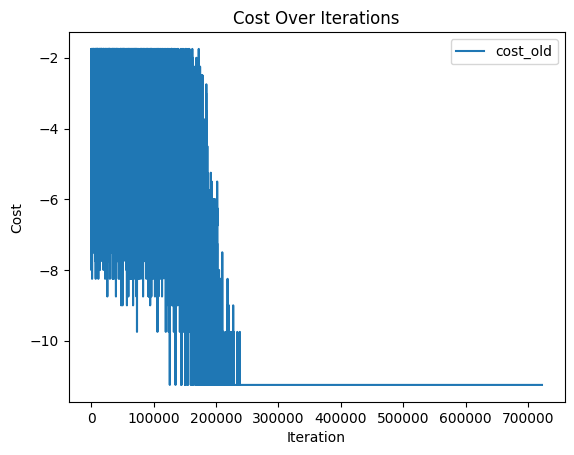

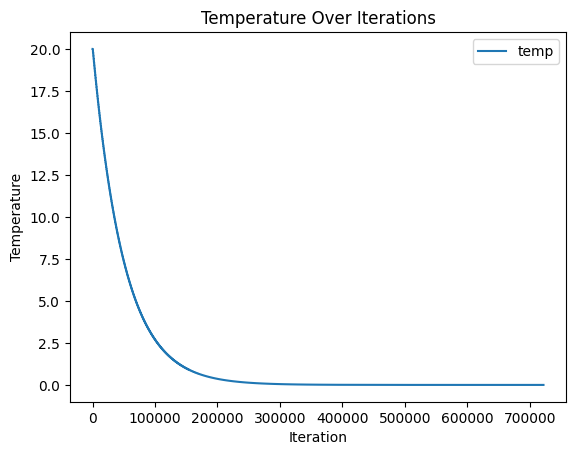

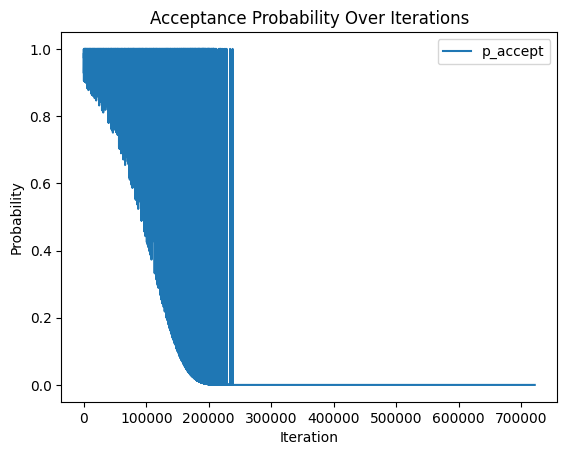

In [10]:
# Function to format and display seating arrangements
def format_and_display_seating(seating_matrix, guest_names):
    """
    Formats and prints the seating arrangement.

    Parameters:
    - seating_matrix: 2D array indicating seating arrangement (1 for seated, 0 for not).
    - guest_names: List of guest names corresponding to the seating matrix.

    Returns:
    - None
    """
    for table_num, table in enumerate(seating_matrix, start=1):
        # Retrieve indices of guests seated at the current table
        guest_indices = np.where(np.array(table) == 1)[0]
        # Extract guest names using the indices
        table_guests = [guest_names[i] for i in guest_indices]
        # Format and display
        formatted_guests = ', '.join(table_guests)
        print(f"Table {table_num}: {formatted_guests}")
        
# Initial seating arrangement
initial_seating = generate_random_seating(table_count, guest_list)
initial_cost = cost(initial_seating, relationships_mat)

result = anneal(
    initial_seating=initial_seating,
    relationships_mat=relationships_mat,
    table_count=table_count,
    table_size=table_size,
    temp=20.0,
    temp_min=0.00001,
    alpha=0.99,
    n_iter=500,
    audit=True
)

final_seating, final_cost, audit_data = result

# Extract the 'Full Name' column as a list for seating display
guest_names = df['Full Name'].tolist()

# Display initial arrangement and cost
print("Initial Seating Arrangement:")
format_and_display_seating(initial_seating, guest_names)
print(f"Initial Cost: {initial_cost}\n")

# Display final arrangement and cost
print("Final Seating Arrangement:")
format_and_display_seating(final_seating, guest_names)
print(f"Final Cost: {final_cost}")

# Visualization with audit_data
if audit_data:
    audit_df = pd.DataFrame(audit_data, columns=['cost_new', 'cost_old', 'temp', 'p_accept'])
    audit_df[['cost_old']].plot(title="Cost Over Iterations", ylabel="Cost", xlabel="Iteration")
    plt.show()
    audit_df[['temp']].plot(title="Temperature Over Iterations", ylabel="Temperature", xlabel="Iteration")
    plt.show()
    audit_df[['p_accept']].plot(title="Acceptance Probability Over Iterations", ylabel="Probability", xlabel="Iteration")
    plt.show()